# 01 torchvision ViT 预训练推理

前面已经学完 Transformer Encoder 的主要零件，也做过 CNN 图像分类。现在开始把两条主线接起来：

```text
CNN 阶段：图片、通道、分类头、训练与推理
Attention 阶段：token、MHA、FFN、残差连接、LayerNorm
                         ↓
              Vision Transformer
```

这一课不从零实现 ViT，而是先让官方预训练模型真正跑起来。重点不是只得到一个类别，而是跟踪图片怎样一步步变成 token 序列。

## 1. 为什么现在开始学习 ViT

前面的 CNN 和 Attention 看起来像两条不同的学习路线，但 ViT 正好把它们连接起来。

在 CNN 中，我们已经知道：

```text
图片不是抽象概念，而是 B x C x H x W 的张量。
模型先提取图片特征，最后用分类头输出类别分数。
训练和推理是两个不同阶段。
```

在 Attention 中，我们已经知道：

```text
Transformer Encoder 接收 B x N x D 的 token 序列。
MHA 负责不同 token 之间交换信息。
FFN 负责对每个 token 单独加工。
残差连接和 LayerNorm 让多层结构可以稳定堆叠。
```

现在遇到的关键问题是：图片原本是 `B x C x H x W`，而 Transformer 想接收 `B x N x D`。ViT 最核心的工作，就是在这两种表示之间搭一座桥。

## 2. ViT 到底是什么

ViT 的全称是 Vision Transformer，也就是“用于视觉任务的 Transformer”。

它并不是把整张图片直接塞进 Attention，也不是把每个像素都当成一个 token。标准 ViT 会先把图片切成许多固定大小的小块，每一块叫作一个 patch。

例如，一张 224 x 224 的图片使用 16 x 16 的 patch：

$$
224 / 16 = 14
$$

图片的横向和纵向都能切出 14 块，因此 patch 总数是：

$$
N = 14 \times 14 = 196
$$

每个 patch 再被转换成一个长度为 768 的向量。这样，二维图片就变成了长度为 196 的 token 序列：

$$
B \times 3 \times 224 \times 224
\longrightarrow
B \times 196 \times 768
$$

这里的 196 是 token 数量 $N$，768 是每个 token 的特征维度 $D$。一定不要把这两个数字混在一起。

## 3. 先建立完整的数据流

这一课中，一张图片会经历下面的过程：

```textmate
原始图片
→ Resize、CenterCrop、转 Tensor、标准化
→ 1 x 3 x 224 x 224
→ 切成 196 个 patches，并映射成 768 维向量
→ 1 x 196 x 768
→ 在序列开头加入 1 个 CLS token
→ 1 x 197 x 768
→ 加入位置编码，经过 12 层 Transformer Encoder
→ 1 x 197 x 768
→ 只取第 0 个位置的 CLS 表示
→ 1 x 768
→ 线性分类头
→ 1 x 1000
```

后面的每一段代码，都应该能在这张路线图中找到自己的位置。如果某一行代码不知道在完成哪一步，就先不要急着往后运行。

## 4. 本次实战目标

完成下面这条最小闭环：

```text
加载官方预训练权重
→ 使用权重自带的官方预处理
→ 对一张真实图片分类
→ 查看 Top-5 预测
→ 手动拆开 forward，记录关键 shape
→ 阅读 _process_input、forward 和 EncoderBlock.forward
→ 只改变“是否水平翻转”并比较结果
```

本课使用 `torchvision.models.vit_b_16`。它的 patch 大小是 16 x 16，默认输入大小是 224 x 224。

## 5. 什么是预训练推理

### 什么是预训练模型

如果从随机参数开始训练 `vit_b_16`，就需要大量图片、较长训练时间和合适的训练策略。torchvision 提供的预训练权重已经在 ImageNet-1K 数据集上训练完成。

可以把它理解成：

```text
模型结构：已经定义好
模型参数：已经训练好
类别名称：已经记录好
图片预处理：已经规定好
```

### 什么是推理

推理是让训练好的模型处理新数据并给出预测。它只需要：

```text
新图片 → 前向传播 → 类别分数 → 预测结果
```

推理阶段不计算 loss、不执行 `backward()`、也不使用优化器更新参数。因此，这一课是在观察一个已经学会分类的 ViT 怎样处理图片，不是在训练 ViT。

## 6. 检查环境

预训练权重会缓存在当前 Conda 环境的 `torch-cache` 目录中。第一次运行需要联网下载，之后可以直接复用。

In [1]:
import sys
from io import BytesIO
from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
import torch
import torchvision
from PIL import Image

torch_cache = Path(sys.prefix) / "torch-cache"
torch.hub.set_dir(torch_cache)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("计算设备:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("权重缓存目录:", torch.hub.get_dir())

Python: 3.13.14
PyTorch: 2.10.0
torchvision: 0.25.0
计算设备: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
权重缓存目录: D:\PythonWorkSpace\anaconda\envs\dl-study\torch-cache


### 环境代码逐段理解

这一格代码虽然主要是在准备环境，但每一组导入都有明确用途：

| 工具 | 本课用途 |
|---|---|
| `torch` | 张量运算、设备选择和模型推理 |
| `torchvision` | 提供 ViT 模型、预训练权重和图片变换 |
| `PIL.Image` | 读取真实图片 |
| `matplotlib` | 显示原图和对照实验 |
| `BytesIO` | 把从网络得到的图片字节当成文件读取 |
| `Path` | 创建清晰的缓存路径 |

设备选择代码：

```python
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
```

它的含义是：有可用 CUDA 时使用 GPU，否则自动退回 CPU。这只是确定计算发生在哪里，并不会自动把模型和数据移动过去。后面还要分别调用 `.to(device)`。

实际输出说明当前使用的是 RTX 5060 Laptop GPU。权重放在 `dl-study` Conda 环境自己的 `torch-cache` 中，重复运行时不需要再次下载。

## 7. 加载模型和官方权重

`ViT_B_16_Weights.DEFAULT` 不只代表一份模型参数，还带着与这份参数匹配的：

- 图片预处理规则；
- ImageNet 类别名称；
- 训练权重的元信息。

预训练推理时，模型参数和预处理必须配套使用。`model.eval()` 会把模型切换到推理模式。

In [2]:
from torchvision.models import ViT_B_16_Weights, vit_b_16

weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights=weights).to(device)
model.eval()
preprocess = weights.transforms()
categories = weights.meta["categories"]

parameter_count = sum(p.numel() for p in model.parameters())
print(f"参数量：{parameter_count:,}")
print("Patch Embedding：", model.conv_proj)
print("第一个 EncoderBlock：\n", model.encoder.layers[0])
print("分类头：", model.heads)
print("官方预处理：", preprocess)

参数量：86,567,656
Patch Embedding： Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
第一个 EncoderBlock：
 EncoderBlock(
  (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (self_attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
  )
  (dropout): Dropout(p=0.0, inplace=False)
  (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (mlp): MLPBlock(
    (0): Linear(in_features=768, out_features=3072, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=3072, out_features=768, bias=True)
    (4): Dropout(p=0.0, inplace=False)
  )
)
分类头： Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)
官方预处理： ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


### 加载代码逐行理解

#### `weights = ViT_B_16_Weights.DEFAULT`

选择 torchvision 当前推荐的 `vit_b_16` 预训练权重。`weights` 不只是参数文件地址，还保存了与权重配套的类别名称和预处理配置。

#### `model = vit_b_16(weights=weights)`

先创建 `vit_b_16` 的网络结构，再把训练好的参数装入模型。如果写成 `weights=None`，模型仍然可以前向传播，但随机参数不能直接给出有意义的 ImageNet 预测。

#### `.to(device)`

把模型参数移动到 GPU。后面的输入张量也必须移动到同一设备，否则模型和输入无法计算。

#### `model.eval()`

把模型切换到推理模式。它不会关闭梯度，而是改变 Dropout 等模块在推理时的行为。关闭梯度由后面的 `torch.inference_mode()` 完成。

#### `weights.transforms()`

取得与预训练权重匹配的官方图片预处理。训练时使用什么图片尺度和标准化方式，推理时就应该保持一致。

### 怎样读懂 `vit_b_16`

`vit_b_16` 中，`B` 表示 Base 规模，`16` 表示 patch_size=16。当前模型的关键配置如下：

| 配置 | 数值 | 含义 |
|---|---:|---|
| 输入尺寸 | 224 x 224 | 官方权重要求的裁剪后尺寸 |
| patch_size | 16 | 每个 patch 是 16 x 16 |
| patch 数量 | 196 | 14 x 14 个 patch |
| hidden_dim | 768 | 每个 token 的向量长度 |
| Encoder 深度 | 12 | 堆叠 12 个 EncoderBlock |
| 注意力头数 | 12 | 每层 MHA 使用 12 个 head |
| FFN 隐藏维度 | 3072 | 从 768 扩张到 3072，再压回 768 |
| 输出类别数 | 1000 | ImageNet-1K 分类 |
| 参数量 | 约 8657 万 | 所有可学习参数的总数 |

最容易混淆的是 16 和 768：16 是 patch 的边长，768 是 patch 转换成 token 后的特征维度。

### 怎样阅读打印出来的模型片段

Patch Embedding 显示为：

```text
Conv2d(3, 768, kernel_size=16, stride=16)
```

从 CNN 知识可以读出：输入有 3 个 RGB 通道；输出有 768 个通道；卷积核大小是 16；步长也是 16。kernel_size 和 stride 相等，所以相邻 patch 不重叠。

第一个 EncoderBlock 中可以看到：

```text
LayerNorm
MultiheadAttention
LayerNorm
Linear(768 → 3072)
GELU
Linear(3072 → 768)
```

GELU是一种激活函数

$$
\operatorname{GELU}(x)=x\cdot\Phi(x)=x\cdot\frac{1}{2}\left[1+\operatorname{erf}\!\left(\frac{x}{\sqrt{2}}\right)\right]
$$

和 ReLU 一样,对负数有抑制作用,正数基本保留。

但它是平滑的:不是硬性地把负数砍成 0,而是按 $x$ 是正数的"概率"来缩放.

可以看成是 ReLU 的"概率化/平滑版":x * P(x>0)。

这正是前面学过的 MHA + FFN。torchvision 当前实现把 LayerNorm 放在子层前面，属于 Pre-Norm 写法。

## 8. 准备一张真实图片

下面使用 PyTorch 官方示例仓库中的狗图片。图片只读入内存，不会额外散落在学习目录中。

官方预处理会完成 Resize、CenterCrop、转 Tensor 和标准化，最后得到模型要求的 `3 x 224 x 224`。

正常学习时仍建议使用 **Restart Kernel and Run All Cells** 按顺序执行。为了避免跳着运行时出现 `preprocess is not defined`，下面的图片单元也带有依赖检查：如果模型初始化单元尚未运行，它会自动补齐缺失对象。

In [3]:
# 先只打印预处理配置，确认模型真正需要什么输入
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


### 官方预处理的四个步骤

从输出中可以读出下面的过程：

#### 1. Resize 到 256

把图片较短的一边缩放到 256，同时尽量保持宽高比例。此时还不一定是正方形。

#### 2. CenterCrop 到 224 x 224

从图片中心裁剪出模型要求的 224 x 224 区域。`vit_b_16` 的 `_process_input` 会检查高和宽，尺寸不符会直接报错。

#### 3. 转成 Tensor

PIL 图片通常用 `H x W x C` 组织，转换后 PyTorch 图片张量使用 `C x H x W`，并把像素缩放到适合计算的浮点范围。

#### 4. 按通道标准化

每个 RGB 通道分别计算：

$$
x_{normalized}=\frac{x-mean}{std}
$$

这里使用 ImageNet 对应的 mean 和 std。标准化后的数值不再局限于 0 到 1，这是正常现象。

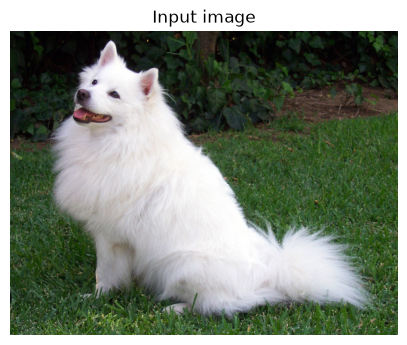

原图尺寸（宽, 高）： (1546, 1213)
预处理后单张图片： (3, 224, 224)
加入 batch 维度后： (1, 3, 224, 224)


In [3]:
# Jupyter 允许跳着执行单元。若上方初始化单元没有运行，先自动补齐依赖。
import sys
from io import BytesIO
from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision.models import ViT_B_16_Weights, vit_b_16

if "torch_cache" not in globals():
    torch_cache = Path(sys.prefix) / "torch-cache"
    torch.hub.set_dir(torch_cache)

if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if "weights" not in globals():
    weights = ViT_B_16_Weights.DEFAULT

if "model" not in globals():
    model = vit_b_16(weights=weights).to(device)
    model.eval()

if "preprocess" not in globals():
    preprocess = weights.transforms()

if "categories" not in globals():
    categories = weights.meta["categories"]

image_url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
with urlopen(image_url, timeout=30) as response:
    image = Image.open(BytesIO(response.read())).convert("RGB")

input_tensor = preprocess(image)
input_batch = input_tensor.unsqueeze(0).to(device)

plt.figure(figsize=(5, 4))
plt.imshow(image)
plt.axis("off")
plt.title("Input image")
plt.show()

print("原图尺寸（宽, 高）：", image.size)
print("预处理后单张图片：", tuple(input_tensor.shape))
print("加入 batch 维度后：", tuple(input_batch.shape))

### 为什么要加入 batch 维度

`preprocess(image)` 得到一张图片：

$$
3 \times 224 \times 224
$$

三个维度分别表示通道、高度和宽度。但神经网络通常统一接收一批数据，因此最前面还要有 batch 维度：

$$
B \times C \times H \times W
$$

这里只预测一张图片，所以 $B=1$。`unsqueeze(0)` 在第 0 个位置插入新维度：

$$
3 \times 224 \times 224
\longrightarrow
1 \times 3 \times 224 \times 224
$$

`.to(device)` 再把输入张量移动到与模型相同的 GPU 上。

### 把 16 x 16 patches 真正画出来

只看 `196` 这个数字仍然比较抽象。下面在经过 Resize 和 CenterCrop、但尚未标准化的图片上画出 14 x 14 网格。每个小方格就是一个 patch。

注意：网格只是为了帮助理解切分位置。模型实际通过一个 kernel_size=16、stride=16 的卷积一次完成切块和线性映射。

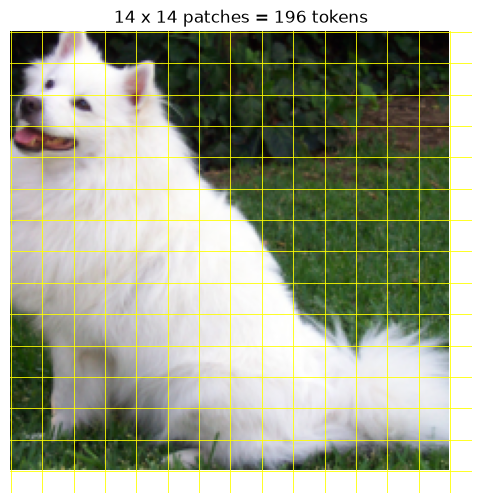

每个 patch： 16 x 16
每行 patch 数： 14
patch 总数： 196


In [4]:
from torchvision.transforms import CenterCrop, Resize

display_image = CenterCrop(224)(Resize(256)(image))
patch_size = model.patch_size
patches_per_side = model.image_size // patch_size

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(display_image)
for position in range(0, model.image_size + 1, patch_size):
    ax.axhline(position, color="yellow", linewidth=0.6)
    ax.axvline(position, color="yellow", linewidth=0.6)
ax.set_title(f"{patches_per_side} x {patches_per_side} patches = {patches_per_side ** 2} tokens")
ax.axis("off")
plt.show()

print("每个 patch：", patch_size, "x", patch_size)
print("每行 patch 数：", patches_per_side)
print("patch 总数：", patches_per_side ** 2)

## 9. 完成一次预训练推理

模型输出的是 1000 个类别的 logits，不是概率。Softmax 把 logits 转换成总和为 1 的概率。

推理时使用 `torch.inference_mode()`，因为这里只需要前向传播，不需要构建反向传播所需的计算图。

In [6]:
# 先确认模型和输入是否位于同一个设备
print("模型参数所在设备：", next(model.parameters()).device)
print("输入张量所在设备：", input_batch.device)

模型参数所在设备： cuda:0
输入张量所在设备： cuda:0


### 先分清 logits、概率和类别

模型最后的线性层输出 1000 个原始分数，这些分数叫 logits。logits 可以是正数、负数，也不要求总和为 1。

Softmax 把第 $i$ 类的 logit 转成概率：

$$
p_i=\frac{e^{z_i}}{\sum_{j=1}^{1000}e^{z_j}}
$$

转换后，每个概率都在 0 到 1 之间，而且 1000 个类别的概率总和为 1。

`topk(5, dim=1)` 沿类别维度选出概率最大的 5 个结果，并同时返回：

```text
top_probabilities：最大的 5 个概率
top_indices：这 5 个概率对应的类别编号
```

类别编号本身只是 0 到 999 的整数，`weights.meta["categories"]` 才能把编号翻译成可读的类别名称。

In [7]:
with torch.inference_mode():
    logits = model(input_batch)
    probabilities = logits.softmax(dim=1)
    top_probabilities, top_indices = probabilities.topk(5, dim=1)

print("logits shape：", tuple(logits.shape))
print("\nTop-5 预测：")
for rank, (probability, class_index) in enumerate(
    zip(top_probabilities[0], top_indices[0]), start=1
):
    print(f"{rank}. {categories[class_index.item()]:20s} {probability.item():.2%}")

logits shape： (1, 1000)

Top-5 预测：
1. Samoyed              79.97%
2. Pomeranian           3.71%
3. keeshond             1.72%
4. Japanese spaniel     0.57%
5. Eskimo dog           0.51%


### 怎样解释这次预测

输出的 `logits shape` 是 `1 x 1000`：

- `1` 表示输入 batch 中只有 1 张图片；
- `1000` 表示 ImageNet-1K 的 1000 个类别；
- 它不是 `1 x 1`，因为模型必须先对所有候选类别给出分数，再选最大者。

Top-1 是 Samoyed，概率约 79.97%。原图确实是一只白色萨摩耶犬，说明模型、权重、预处理和类别名称的组合工作正常。

Top-5 中还出现了 Pomeranian、keeshond、Eskimo dog 等外观相近的犬类。它们不是随机结果，而是说明模型认为这些类别的视觉特征也与图片相似。

不要把 79.97% 理解成现实世界中绝对可靠的“正确概率”。它是模型在 ImageNet 这 1000 个候选类别中的 Softmax 置信度，可能受到数据分布和模型校准情况影响。

## 10. 手动拆开 forward，跟踪关键 shape

对 224 x 224 的图片使用 16 x 16 的 patch：

$$
14 = 224 / 16
$$

所以 patch 数量是：

$$
N = 14 \times 14 = 196
$$

每个 patch 会被映射成一个 768 维 token。再在序列开头加入 1 个 CLS token，序列长度就从 196 变成 197。

```text
B x 3 x 224 x 224
→ B x 768 x 14 x 14
→ B x 196 x 768
→ B x 197 x 768
→ Encoder 后仍是 B x 197 x 768
→ 取 CLS：B x 768
→ 分类头：B x 1000
```

In [8]:
print("conv_proj.weight：", tuple(model.conv_proj.weight.shape))
print("class_token：", tuple(model.class_token.shape))
print("position_embedding：", tuple(model.encoder.pos_embedding.shape))
print("EncoderBlock 数量：", len(model.encoder.layers))

conv_proj.weight： (768, 3, 16, 16)
class_token： (1, 1, 768)
position_embedding： (1, 197, 768)
EncoderBlock 数量： 12


### 第一步：卷积怎样得到 14 x 14

二维卷积的单边输出尺寸公式是：

$$
H_{out}=\left\lfloor\frac{H+2P-K}{S}\right\rfloor+1
$$

当前 $H=224$、padding $P=0$、kernel_size $K=16$、stride $S=16$：

$$
H_{out}=\frac{224-16}{16}+1=14
$$

宽度同样得到 14，因此卷积输出为：

$$
B \times 768 \times 14 \times 14
$$

这里的 768 是卷积的输出通道数，也就是后续 token 的特征维度 $D$。14 x 14 是 patch 在空间上的排列。

### 为什么一个卷积就能完成 Patch Embedding

先记住最关键的结论：ViT 不会把 R、G、B 三个通道分别变成三个 token。它会把同一个空间区域内的三个通道放在一起，生成一个 patch token。

假设一张小图片的形状是 $3\times4\times4$，patch 边长 $P=2$。空间上一共能切出 $N=(4/2)^2=4$ 个 patch，每个 patch 同时包含三个通道，因此拥有 $3\times2\times2=12$ 个原始像素值。

把一个 patch 的 RGB 像素展平，再使用所有 patch 共享的可学习投影，就能得到一个 $D$ 维 token：

$$
\underbrace{\mathbf{p}_j\in\mathbb{R}^{3P^2}}_{\text{第 }j\text{ 个 RGB patch}}
\xrightarrow{\text{线性投影}}
\underbrace{\mathbf{z}_j\in\mathbb{R}^{D}}_{\text{第 }j\text{ 个 patch token}}
$$

所以，小图片的变化可以浓缩为：

$$
3\times4\times4
\xrightarrow{\text{切分 patches}}
4\times12
\xrightarrow{\text{Patch Embedding}}
4\times D
$$

这里的 4 是 token 数量，每个 token 都融合了对应区域的全部 RGB 信息。一般规律是 $3P^2\xrightarrow{\text{可学习投影}}D$。图片标准化只改变像素数值，不会生成 token；真正生成 token 的是 Patch Embedding。

一个 RGB patch 中有：

$$
3 \times 16 \times 16 = 768
$$

个原始像素值。`conv_proj.weight` 的形状是 $768\times3\times16\times16$。可以把 768 个卷积核理解成 768 个不同的特征提取器：每个卷积核读取完整的 RGB patch，输出一个数；768 个卷积核一起输出一个 768 维向量。

因此，对单个 patch 来说，这个卷积等价于一次可学习的线性映射：

$$
\mathbb{R}^{3\times16\times16}
\longrightarrow
\mathbb{R}^{768}
$$

恰好在 ViT-B/16 中，原始 patch 展平长度和 hidden_dim 都是 768，但这是配置上的巧合，不是 ViT 的硬性要求。以后实现 Tiny ViT 时，$3\times4\times4=48$ 完全可以映射到 $D=192$。

### 第二步：为什么还要 reshape 和 permute

卷积输出仍采用 CNN 常见的格式：

$$
B \times D \times H_p \times W_p
= B \times 768 \times 14 \times 14
$$

Transformer 想要的是 token 序列格式 `B x N x D`，所以 `_process_input` 分两步转换。

先把 14 x 14 的空间位置展平：

$$
B \times 768 \times 14 \times 14
\xrightarrow{reshape}
B \times 768 \times 196
$$

再交换最后两个维度：

$$
B \times 768 \times 196
\xrightarrow{permute(0,2,1)}
B \times 196 \times 768
$$

现在第 1 维是 token 数量，第 2 维是每个 token 的特征，终于与 Transformer Encoder 的 `B x N x D` 约定一致。

### 第三步：CLS token 和位置编码分别解决什么问题

#### CLS token

`model.class_token` 的参数形状是 `1 x 1 x 768`。第一个 1 表示它先只保存一份模板，第二个 1 表示只有一个特殊 token。

输入 batch 中有 $B$ 张图片时，`expand(B, -1, -1)` 让每张图片都使用同一组可学习 CLS 参数：

$$
1 \times 1 \times 768
\longrightarrow
B \times 1 \times 768
$$

把它拼到 196 个 patch tokens 前面后，序列长度变为 197。经过 Self-Attention，CLS 可以读取各个 patch 的信息，逐层形成整张图片的汇总表示。

#### 位置编码

Self-Attention 本身不知道某个 patch 位于左上角还是右下角。`position_embedding` 的形状是 `1 x 197 x 768`，它为 CLS 和每个 patch 位置提供不同的可学习位置向量。

二者的分工不同：

```text
CLS token：提供用于最终分类的特殊信息汇总位置
位置编码：告诉模型每个 token 原本位于哪里
```

In [9]:
with torch.inference_mode():
    patch_feature_map = model.conv_proj(input_batch)
    patch_tokens = model._process_input(input_batch)

    batch_size = patch_tokens.shape[0]
    cls_token = model.class_token.expand(batch_size, -1, -1)
    tokens_with_cls = torch.cat([cls_token, patch_tokens], dim=1)
    tokens_with_position = tokens_with_cls + model.encoder.pos_embedding

    # model.encoder 会在内部加入同一份位置编码
    encoder_output = model.encoder(tokens_with_cls)
    cls_output = encoder_output[:, 0]
    manual_logits = model.heads(cls_output)

shape_records = [
    ("输入图片", input_batch),
    ("卷积形式的 Patch Embedding", patch_feature_map),
    ("展平后的 patch tokens", patch_tokens),
    ("CLS token", cls_token),
    ("加入 CLS 后的 tokens", tokens_with_cls),
    ("加入位置编码后的 tokens", tokens_with_position),
    ("Transformer Encoder 输出", encoder_output),
    ("取出的 CLS 表示", cls_output),
    ("分类 logits", manual_logits),
]

for name, tensor in shape_records:
    print(f"{name:28s} -> {tuple(tensor.shape)}")

print("\n手动拆解结果与 model(input) 是否一致：", torch.allclose(logits, manual_logits))

输入图片                         -> (1, 3, 224, 224)
卷积形式的 Patch Embedding        -> (1, 768, 14, 14)
展平后的 patch tokens            -> (1, 196, 768)
CLS token                    -> (1, 1, 768)
加入 CLS 后的 tokens             -> (1, 197, 768)
加入位置编码后的 tokens              -> (1, 197, 768)
Transformer Encoder 输出       -> (1, 197, 768)
取出的 CLS 表示                   -> (1, 768)
分类 logits                    -> (1, 1000)

手动拆解结果与 model(input) 是否一致： True


### 手动拆解代码逐行对应

现在不要只看最终打印结果，要把代码和数学含义对应起来。

#### `model.conv_proj(input_batch)`

只执行卷积形式的 Patch Embedding，保留 14 x 14 空间排列，所以得到 `1 x 768 x 14 x 14`。

#### `model._process_input(input_batch)`

执行同一个卷积后继续 reshape 和 permute，得到 `1 x 196 x 768`。这里已经是 token 序列，但还没有 CLS token。

#### `torch.cat([cls_token, patch_tokens], dim=1)`

沿 token 维度拼接。因为拼接的是第 1 维，序列长度从 1+196 变成 197，特征维 768 不变。

#### `tokens_with_cls + position_embedding`

两个张量都是 `1 x 197 x 768`，逐元素相加后形状不变。这里额外计算一份只是为了观察 shape；真正调用 `model.encoder(tokens_with_cls)` 时，Encoder 会在内部完成同样的位置编码相加。

#### `encoder_output[:, 0]`

冒号表示保留所有 batch，`0` 表示只取 token 维度上的第 0 个位置，也就是 CLS。于是：

$$
B \times 197 \times 768
\longrightarrow
B \times 768
$$

#### `model.heads(cls_output)`

线性层把每张图片的 768 维 CLS 表示映射到 1000 个类别 logits。

最后 `torch.allclose(logits, manual_logits)` 为 True，证明手动拆解没有改变官方 forward 的数据流。

## 11. 把 ViT 对应到已经学过的知识

### Patch Embedding

`conv_proj` 使用 kernel_size=16、stride=16 的卷积。卷积窗口互不重叠，每个窗口正好对应一个 patch。768 个卷积核把每个 patch 映射成 768 个特征。

它和 CNN 的卷积形式相似，但这里的主要目的不是逐层提取局部特征，而是把图片切成 token。

### CLS token

CLS token 是一个可学习向量。它和 196 个 patch tokens 一起经过 Encoder。多层 Self-Attention 让它汇总整张图片的信息，最后分类头只读取这个位置。

### Encoder

这里就是已经学过的 Transformer Encoder：

```text
Multi-Head Self-Attention
→ 残差连接 + LayerNorm
→ FFN
→ 残差连接 + LayerNorm
```

Encoder 改写 token 的内容，但保持 `B x N x D` 不变，所以输入和输出都是 `B x 197 x 768`。

## 12. 第一遍阅读 torchvision 源码

不要从源码第一行读到最后一行。先只看数据流入口：

1. `_process_input`：图片怎样变成 patch tokens；
2. `VisionTransformer.forward`：怎样加 CLS、进 Encoder、取 CLS、进分类头；
3. `EncoderBlock.forward`：MHA、残差连接、LayerNorm 和 FFN 怎样连接。

下面直接读取当前环境中实际执行的源码，避免网页源码与本地版本不一致。

In [10]:
import inspect
from torchvision.models.vision_transformer import Encoder, EncoderBlock, VisionTransformer

for title, function in [
    ("VisionTransformer._process_input", VisionTransformer._process_input),
    ("VisionTransformer.forward", VisionTransformer.forward),
    ("Encoder.forward", Encoder.forward),
    ("EncoderBlock.forward", EncoderBlock.forward),
]:
    print(f"\n{'=' * 20} {title} {'=' * 20}")
    print(inspect.getsource(function))


==================== VisionTransformer._process_input ====================
    def _process_input(self, x: torch.Tensor) -> torch.Tensor:
        n, c, h, w = x.shape
        p = self.patch_size
        torch._assert(h == self.image_size, f"Wrong image height! Expected {self.image_size} but got {h}!")
        torch._assert(w == self.image_size, f"Wrong image width! Expected {self.image_size} but got {w}!")
        n_h = h // p
        n_w = w // p

        # (n, c, h, w) -> (n, hidden_dim, n_h, n_w)
        x = self.conv_proj(x)
        # (n, hidden_dim, n_h, n_w) -> (n, hidden_dim, (n_h * n_w))
        x = x.reshape(n, self.hidden_dim, n_h * n_w)

        # (n, hidden_dim, (n_h * n_w)) -> (n, (n_h * n_w), hidden_dim)
        # The self attention layer expects inputs in the format (N, S, E)
        # where S is the source sequence length, N is the batch size, E is the
        # embedding dimension
        x = x.permute(0, 2, 1)

        return x


==================== VisionTransforme

### 把源码翻译成已经学过的知识

#### `_process_input`

```text
n, c, h, w = x.shape       读取 B、C、H、W
p = self.patch_size        读取 patch_size=16
torch._assert(...)         检查输入必须是 224 x 224
self.conv_proj(x)          切 patch 并映射到 hidden_dim
reshape(...)               把 14 x 14 展平成 196
permute(0, 2, 1)           从 B x D x N 换成 B x N x D
```

#### `VisionTransformer.forward`

```text
_process_input             图片变成 patch tokens
class_token.expand         为 batch 中每张图片准备 CLS
torch.cat                  把 CLS 拼到序列开头
self.encoder               加位置编码并经过 12 层 EncoderBlock
x[:, 0]                    只取 CLS 输出
self.heads                 得到 1000 个类别 logits
```

这段 forward 非常短，说明 ViT 的整体思路并不神秘。复杂计算主要被封装在 Patch Embedding 和 EncoderBlock 内部。

#### `Encoder.forward`

Encoder 先做 `input + pos_embedding`，再按顺序通过 12 个 EncoderBlock，最后还有一次 LayerNorm。位置编码不是在 `_process_input` 中加入的，也不是在外层 `VisionTransformer.forward` 中显式加入的，而是在 Encoder 内部加入。

#### `EncoderBlock.forward`

第一段：

$$
x = input + MHA(LN(input))
$$

第二段：

$$
output = x + FFN(LN(x))
$$

LayerNorm 位于 MHA 和 FFN 之前，所以这是 Pre-Norm。前面理论课见过的经典 Post-Norm 常写成 `LN(x + MHA(x))`。两者零件相同，但顺序不同。阅读源码时应该按实际代码判断，而不是强行套用一种固定顺序。

`self_attention(x, x, x)` 中 Q、K、V 都来自同一份 x，因此它确实是 Self-Attention。`need_weights=False` 表示这次前向传播不返回注意力权重；后续做 Attention Map 时需要采用额外方法获取它。

## 13. 做一次最小对照实验

保持模型、权重和预处理完全不变，只把输入图片水平翻转。比较两次 Top-1 结果，观察模型对这种变化是否稳定。

这就是后续实验应坚持的习惯：每次只改变一个变量。

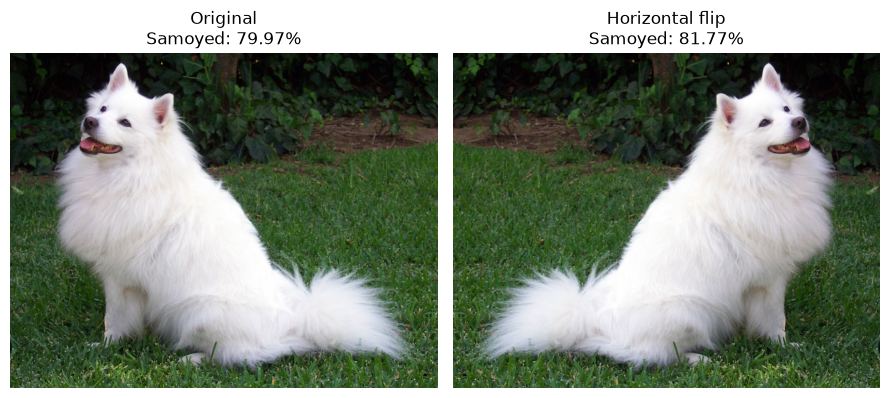

原图 Top-1： Samoyed 79.97%
翻转图 Top-1： Samoyed 81.77%
Top-1 类别是否保持一致： True
同一类别的置信度变化：+1.80%


In [11]:
from torchvision.transforms import functional as TF

flipped_image = TF.hflip(image)
flipped_batch = preprocess(flipped_image).unsqueeze(0).to(device)

with torch.inference_mode():
    flipped_probabilities = model(flipped_batch).softmax(dim=1)

original_index = probabilities[0].argmax().item()
flipped_index = flipped_probabilities[0].argmax().item()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(image)
axes[0].set_title(
    f"Original\n{categories[original_index]}: {probabilities[0, original_index].item():.2%}"
)
axes[1].imshow(flipped_image)
axes[1].set_title(
    f"Horizontal flip\n{categories[flipped_index]}: {flipped_probabilities[0, flipped_index].item():.2%}"
)
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

print("原图 Top-1：", categories[original_index], f"{probabilities[0, original_index].item():.2%}")
print("翻转图 Top-1：", categories[flipped_index], f"{flipped_probabilities[0, flipped_index].item():.2%}")
print("Top-1 类别是否保持一致：", original_index == flipped_index)
if original_index == flipped_index:
    confidence_change = (
        flipped_probabilities[0, flipped_index] - probabilities[0, original_index]
    ).item()
    print(f"同一类别的置信度变化：{confidence_change:+.2%}")

### 对照实验说明了什么

水平翻转后，Top-1 仍然是 Samoyed，说明对这张图片和这个模型而言，左右方向改变没有破坏最关键的犬类特征。

但“类别相同”不代表模型内部表示完全相同。两个输入的像素位置发生了变化，patch tokens、注意力关系和最终概率都可能变化。我们同时打印置信度变化，就是为了避免只看一个类别名称便过早下结论。

这个实验也不能证明 ViT 天然具有水平翻转不变性。更严谨的结论应该是：

```text
在当前模型、当前图片和当前变换下，Top-1 类别保持一致。
```

如果要研究模型是否普遍稳定，需要在许多图片上重复实验并统计准确率，而不是只观察一个样本。

## 14. 把一次推理整理成可复用函数

前面为了学习数据流，把每一步拆开写得很清楚。真正反复预测不同图片时，可以把固定流程封装成函数。

这个函数只负责：预处理、加入 batch、移动设备、前向传播、Softmax 和 Top-k。模型加载仍然放在函数外面，避免每预测一张图片就重新加载一次 8657 万参数的模型。

In [12]:
def predict_topk(pil_image, k=5):
    batch = preprocess(pil_image).unsqueeze(0).to(device)
    with torch.inference_mode():
        probs = model(batch).softmax(dim=1)
    values, indices = probs[0].topk(k)
    return [
        (categories[index.item()], value.item())
        for value, index in zip(values, indices)
    ]

for rank, (class_name, probability) in enumerate(predict_topk(image, k=3), start=1):
    print(f"{rank}. {class_name}: {probability:.2%}")

1. Samoyed: 79.97%
2. Pomeranian: 3.71%
3. keeshond: 1.72%


## 15. 本课动手任务

不要只从上到下运行一次。建议按顺序完成下面的修改，每次只改变一个变量。

### 任务一：不看输出，自己写出 shape

先清空或遮住 shape 跟踪单元的输出，独立写出：

```text
输入图片
conv_proj 输出
patch tokens
加入 CLS 后
Encoder 输出
CLS 输出
分类 logits
```

然后运行代码逐项核对。能预测 shape 比能看懂打印结果更重要。

### 任务二：把 Top-5 改成 Top-3

把 `topk(5, dim=1)` 改成 `topk(3, dim=1)`，观察发生变化的是输出数量还是模型本身。正确理解是：模型仍然输出 1000 个 logits，只是我们最后只读取最大的 3 个。

### 任务三：替换一张自己的图片

使用 `Image.open(图片路径).convert("RGB")` 读取自己的图片，再调用 `predict_topk`。记录 Top-5 是否合理。注意 ImageNet 只认识预先规定的 1000 个类别，自己的图片不一定属于其中任何一类。

### 任务四：观察输入尺寸检查

不要修改当前已跑通的主代码。新建临时单元，把一个没有经过官方预处理的图片张量传给 `_process_input`，阅读报错中的期望尺寸和实际尺寸。完成后删除临时单元。这个练习用来理解源码中的 `torch._assert`。

### 任务五：用自己的话解释卷积为什么等价于 patch 投影

至少说出 kernel_size=16、stride=16、输出通道=768 分别控制什么。如果只能记住 `conv_proj` 这个名字，还不算真正理解。

## 16. 常见问题

### 为什么不能随便写一套预处理

预训练权重是在特定图片尺寸和标准化规则下学到的。预处理不匹配时，即使代码能运行，预测质量也可能明显下降。

### 为什么输入要 `unsqueeze(0)`

预处理后是单张图片 `3 x 224 x 224`，模型要求带 batch 维度的 `B x 3 x 224 x 224`。加入一个维度后得到 `1 x 3 x 224 x 224`。

### 为什么必须 `eval()`

训练模式和推理模式下，Dropout 等模块的行为不同。预训练推理应使用推理模式，保证结果稳定。

### 为什么分类头输出 1000 个数

这份权重在 ImageNet-1K 上训练，对应 1000 个类别，所以输出是 `B x 1000`。

## 17. 本节小结

这一课已经完成了第一个 ViT 实践闭环：

```text
真实图片
→ 官方预处理
→ 16 x 16 patches
→ 196 个 patch tokens
→ 加入 CLS 后得到 197 个 tokens
→ Transformer Encoder
→ 读取 CLS 表示
→ ImageNet 1000 类分类头
```

最重要的 shape 路线是：

```text
1 x 3 x 224 x 224
→ 1 x 196 x 768
→ 1 x 197 x 768
→ 1 x 197 x 768
→ 1 x 768
→ 1 x 1000
```

下一课应继续拆解 `Patch Embedding`，用更小的假图片亲手验证卷积切 patch、展平和转置的每一步。

### 完成本课后应该真正掌握什么

不要用“代码运行成功”判断自己是否学会。更重要的完成标准是：

- 能解释预训练模型与推理分别是什么；
- 能说明为什么权重、预处理和类别名称必须配套；
- 能独立计算 224 x 224 图片使用 16 x 16 patch 时的 patch 数量；
- 能解释卷积如何同时完成切 patch 和线性投影；
- 能从 `B x 768 x 14 x 14` 推到 `B x 196 x 768`；
- 能区分 patch 数量 196、序列长度 197 和特征维度 768；
- 能分别解释 CLS token 与位置编码；
- 能把 torchvision forward 中的每一行对应到 ViT 数据流；
- 能说明当前 EncoderBlock 为什么属于 Pre-Norm；
- 能自己替换图片并完成一次 Top-k 推理；
- 能进行只改变一个变量的简单对照实验。

## 18. 自测问题

1. `vit_b_16` 中的 16 表示什么？
2. 224 x 224 的图片为什么会得到 196 个 patch tokens？
3. patch token 的维度 768 和 patch 数量 196 分别表示什么？
4. 加入 CLS token 后，序列长度为什么是 197？
5. CLS token 怎样得到整张图片的信息？
6. 为什么 Encoder 前后都是 `B x 197 x 768`？
7. `model.eval()` 和 `torch.inference_mode()` 分别解决什么问题？
8. 模型为什么输出 logits，而不是直接输出类别名称？
9. `_process_input` 完成了哪几次 shape 变化？
10. ViT 的 Patch Embedding 与 CNN 卷积有哪些相似和不同？
11. 位置编码的形状为什么是 `1 x 197 x 768`？
12. torchvision 的 EncoderBlock 是 Pre-Norm 还是 Post-Norm？从哪几行源码能判断？
13. `weights.transforms()` 为什么应该和预训练权重配套使用？
14. 为什么只翻转一张图片不能证明模型具有普遍的翻转不变性？
15. 如果把 Top-5 改为 Top-3，模型输出的 logits shape 会改变吗？为什么？

### 自测参考答案

建议先独立回答，再核对下面的关键词。

1. 16 表示 patch 的高和宽都是 16 像素。
2. 每边有 224/16=14 个 patch，总数是 14 x 14=196。
3. 196 是 token 数量 $N$；768 是每个 token 的特征维度 $D$。
4. 在 196 个 patch tokens 前加入了 1 个 CLS token。
5. CLS 与所有 patch tokens 一起经过多层 Self-Attention，逐层汇总图片信息。
6. MHA 和 FFN 最终都会映射回 768 维，token 数量也不变，便于残差连接和多层堆叠。
7. `eval()` 切换模块行为；`inference_mode()` 关闭推理时不需要的梯度记录。
8. 线性分类头对 1000 个候选类别输出分数；类别名称需要通过最大分数的索引查询。
9. `B x 3 x 224 x 224 → B x 768 x 14 x 14 → B x 768 x 196 → B x 196 x 768`。
10. 二者都可使用卷积计算；ViT 这里主要用不重叠卷积把每个 patch 映射成 token，而经典 CNN 通常逐层提取局部特征。
11. 序列有 1 个 CLS 和 196 个 patch 位置，每个位置向量为 768 维；开头的 1 让同一组位置参数可用于整个 batch。
12. Pre-Norm。源码先执行 `ln_1(input)` 再送入 Attention，先执行 `ln_2(x)` 再送入 MLP。
13. 预训练参数是在特定输入尺寸和标准化分布下学习的，预处理不匹配会造成输入分布偏移。
14. 单个样本只能说明当前图片的结果，不能代表大量不同图片上的统计表现。
15. 不会。模型仍输出 `B x 1000`，Top-k 只是在模型输出之后选取其中最大的 k 个。